In [18]:
from typing import TypedDict
from langgraph.graph import START, END, StateGraph
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
load_dotenv()

True

In [19]:
class TestState(TypedDict):
    title: str
    content: str
    quiz: str
    summary: str

In [20]:
llm = ChatOpenAI(model="gpt-4", temperature=0)

In [21]:
def content_creator(state: TestState) -> TestState:
    # Create the content for the test
    title = state["title"]
    prompt_template = ChatPromptTemplate.from_template("Write a 100-word story about {title}.")
    chain = prompt_template | llm
    response = chain.invoke({"title": title})
    return {"content": response.content}

def quiz_creator(state: TestState) -> TestState:
    # Create a quiz based on the content
    content = state["content"]
    prompt_template = ChatPromptTemplate.from_template("Create a 5-question multiple choicequiz based on the following content: {content}")
    chain = prompt_template | llm
    response = chain.invoke({"content": content})
    return {"quiz": response.content}

def summary_creator(state: TestState) -> TestState:
    # Create a summary of the content
    content = state["content"]
    prompt_template = ChatPromptTemplate.from_template("Summarize the following content in one sentence: {content}")
    chain = prompt_template | llm
    response = chain.invoke({"content": content})
    return {"summary": response.content}

In [22]:
# Create a parallel workflow for the test

graph = StateGraph(TestState)

graph.add_node("content", content_creator)
graph.add_node("quiz", quiz_creator)
graph.add_node("summary", summary_creator)

graph.add_edge(START, "content")
graph.add_edge("content", "quiz")
graph.add_edge("content", "summary")
graph.add_edge("quiz", END)
graph.add_edge("summary", END)

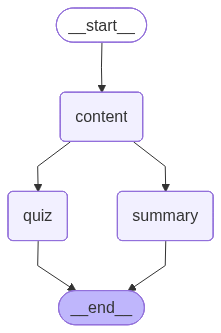

In [23]:
app = graph.compile()
app

In [26]:
initial_state = {"title": "The Great Barrier Reef"}
result = app.invoke(initial_state)
print("\nContent:")
print(result['content'])
print("\nSummary:")
print(result['summary'])
print("\nQuiz:")
print(result['quiz'])


Content:
In the heart of the Coral Sea, the Great Barrier Reef, a vibrant underwater city, thrives. Home to countless species, it paints a kaleidoscope of life beneath the waves. However, climate change threatens this aquatic paradise. Coral bleaching, a ghostly transformation, is stealing its vivid hues. Yet, hope persists. Scientists, divers, and conservationists unite, working tirelessly to protect and restore this natural wonder. Their efforts, a testament to human resilience, echo the reef's own struggle for survival. The Great Barrier Reef, a symbol of nature's beauty and fragility, continues to inspire awe and ignite a global fight for its preservation.

Summary:
The Great Barrier Reef, a vibrant underwater ecosystem in the Coral Sea, is threatened by climate change and coral bleaching, but scientists, divers, and conservationists are working tirelessly to protect and restore this natural wonder, symbolizing both nature's beauty and fragility.

Quiz:
1. Where is the Great Barri